# Task 1: EDA and Data Quality


---
## Install and Import


In [1]:
!pip install missingno -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

print(f'pandas   : {pd.__version__}')
print(f'numpy    : {np.__version__}')
print(f'seaborn  : {sns.__version__}')

pandas   : 2.2.2
numpy    : 2.0.2
seaborn  : 0.13.2


---
## Load Data


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Loan_default.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nikhil1e9/loan-default",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

100%|██████████| 7.86M/7.86M [00:00<00:00, 43.4MB/s]

Extracting zip of Loan_default.csv...


First 5 records:        LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4       15.2300        36    0.4400   Bachelor's   
1               1        4.8100        60    0.6800     Master's   
2               3       21.1700        24    0.3100     Master's   
3               3        7.0700        24    0.2300  High School   
4               4        6.5100        48    0.7300   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1  

In [3]:
# The dataset 'df' has already been loaded in the previous cell using kagglehub.load_dataset.
# No need to reload here. Simply display its properties.

print(f'\nShape            : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nFirst 3 rows:')
df.head(3)


Shape            : 255,347 rows  x  18 columns
Memory usage     : 133.0 MB

First 3 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.2300,36,0.4400,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.8100,60,0.6800,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.1700,24,0.3100,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1


---
## Feature Catalogue


In [4]:
print('=== FEATURE CATALOGUE ===')
print(f'Total features: {df.shape[1]}\n')

# dtypes overview
dtype_summary = df.dtypes.value_counts()
print('Data types:')
for dtype, count in dtype_summary.items():
    print(f'  {str(dtype):<12}: {count} columns')

print('\n--- All columns ---')
for i, (col, dtype) in enumerate(df.dtypes.items()):
    n_unique = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = null_count / len(df) * 100
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f'  {i+1:>2}. {col:<35} {str(dtype):<10} '
          f'unique={n_unique:>6,}  null={null_pct:>5.1f}%  sample={sample}')

=== FEATURE CATALOGUE ===
Total features: 18

Data types:
  object      : 8 columns
  int64       : 8 columns
  float64     : 2 columns

--- All columns ---
   1. LoanID                              object     unique=255,347  null=  0.0%  sample=I38PQUQS96
   2. Age                                 int64      unique=    52  null=  0.0%  sample=56
   3. Income                              int64      unique=114,620  null=  0.0%  sample=85994
   4. LoanAmount                          int64      unique=158,729  null=  0.0%  sample=50587
   5. CreditScore                         int64      unique=   550  null=  0.0%  sample=520
   6. MonthsEmployed                      int64      unique=   120  null=  0.0%  sample=80
   7. NumCreditLines                      int64      unique=     4  null=  0.0%  sample=4
   8. InterestRate                        float64    unique= 2,301  null=  0.0%  sample=15.23
   9. LoanTerm                            int64      unique=     5  null=  0.0%  sample=36
  10

In [5]:
print('=== FEATURE CATALOGUE ===')
print(f'Total features: {df.shape[1]}\n')

# dtypes overview
dtype_summary = df.dtypes.value_counts()
print('Data types:')
for dtype, count in dtype_summary.items():
    print(f'  {str(dtype):<12}: {count} columns')

print('\n--- All columns ---')
for i, (col, dtype) in enumerate(df.dtypes.items()):
    n_unique = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = null_count / len(df) * 100
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f'  {i+1:>2}. {col:<35} {str(dtype):<10} '
          f'unique={n_unique:>6,}  null={null_pct:>5.1f}%  sample={sample}')

=== FEATURE CATALOGUE ===
Total features: 18

Data types:
  object      : 8 columns
  int64       : 8 columns
  float64     : 2 columns

--- All columns ---
   1. LoanID                              object     unique=255,347  null=  0.0%  sample=I38PQUQS96
   2. Age                                 int64      unique=    52  null=  0.0%  sample=56
   3. Income                              int64      unique=114,620  null=  0.0%  sample=85994
   4. LoanAmount                          int64      unique=158,729  null=  0.0%  sample=50587
   5. CreditScore                         int64      unique=   550  null=  0.0%  sample=520
   6. MonthsEmployed                      int64      unique=   120  null=  0.0%  sample=80
   7. NumCreditLines                      int64      unique=     4  null=  0.0%  sample=4
   8. InterestRate                        float64    unique= 2,301  null=  0.0%  sample=15.23
   9. LoanTerm                            int64      unique=     5  null=  0.0%  sample=36
  10

---
## Target Variable Analysis

=== TARGET VARIABLE ANALYSIS ===

Column name      : Default
Non-default (0)  :  225,694  (88.4%)
Default (1)      :   29,653  (11.6%)
Imbalance ratio  : 7.6 : 1

Baseline accuracy (predict majority always): 88.4%
Your model MUST beat this — but beating it by 1% is meaningless.
Focus on PR-AUC and F1 at the optimal threshold.


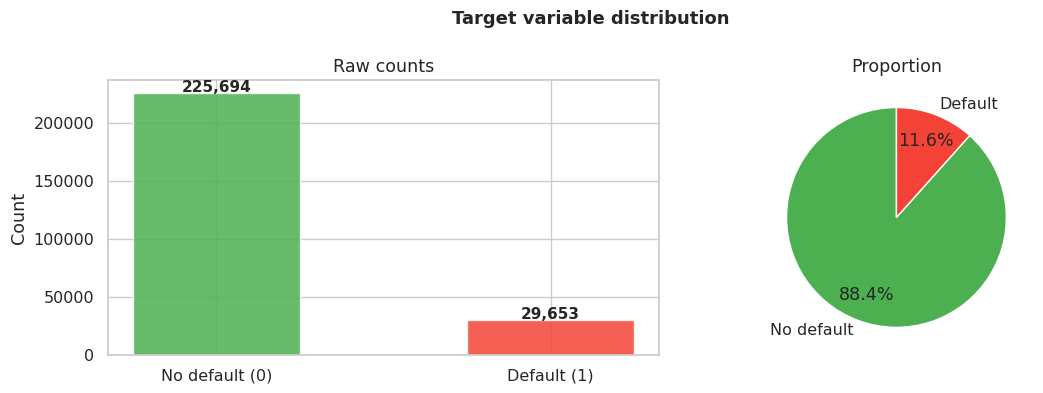

In [6]:
target_col = 'Default'

counts = df[target_col].value_counts()
pcts   = df[target_col].value_counts(normalize=True) * 100

print('=== TARGET VARIABLE ANALYSIS ===')
print(f'\nColumn name      : {target_col}')
print(f'Non-default (0)  : {counts[0]:>8,}  ({pcts[0]:.1f}%)')
print(f'Default (1)      : {counts[1]:>8,}  ({pcts[1]:.1f}%)')
print(f'Imbalance ratio  : {counts[0]/counts[1]:.1f} : 1')
print(f'\nBaseline accuracy (predict majority always): {pcts[0]:.1f}%')
print(f'Your model MUST beat this — but beating it by 1% is meaningless.')
print(f'Focus on PR-AUC and F1 at the optimal threshold.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target variable distribution', fontsize=13, fontweight='bold')

# Count plot
axes[0].bar(['No default (0)', 'Default (1)'], counts.values,
            color=['#4CAF50', '#F44336'], alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Raw counts')
for i, (label, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 1000, f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['No default', 'Default'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, pctdistance=0.75)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Missing Value Audit


=== MISSING VALUE AUDIT ===

No missing values found in any column.
This is unusual for real-world loan data — verify the dataset.


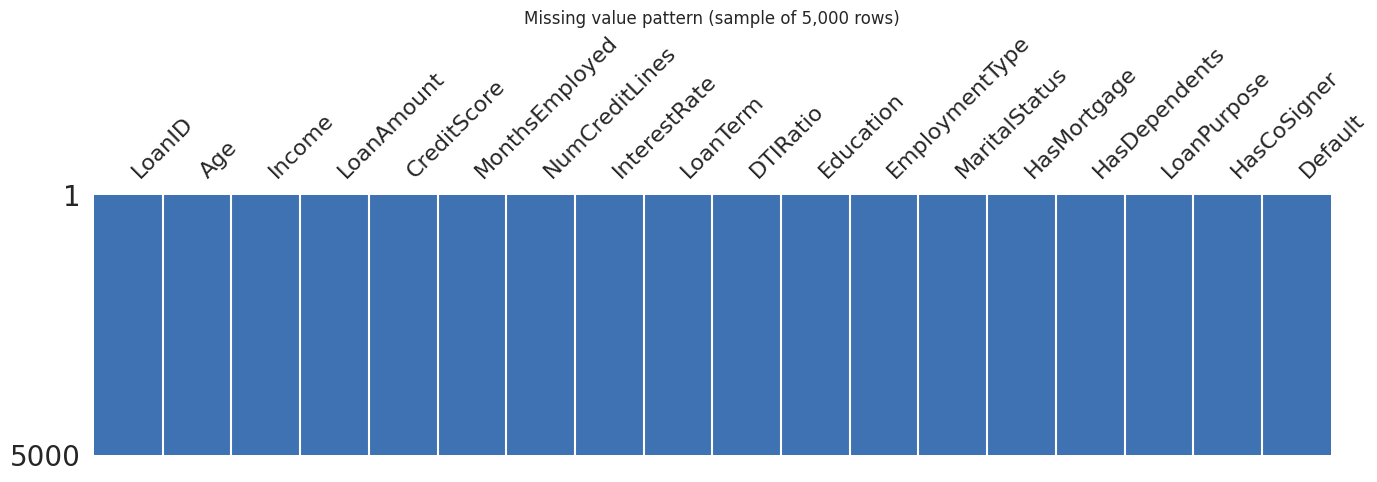

In [7]:
print('=== MISSING VALUE AUDIT ===\n')

missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_df = missing_df[missing_df['missing_count'] > 0]

if len(missing_df) == 0:
    print('No missing values found in any column.')
    print('This is unusual for real-world loan data — verify the dataset.')
else:
    print(f'Columns with missing values: {len(missing_df)}')
    print()
    for col, row in missing_df.iterrows():
        severity = 'HIGH' if row['missing_pct'] > 20 else ('MED' if row['missing_pct'] > 5 else 'LOW')
        print(f'  {col:<35} {row["missing_count"]:>6,} rows  ({row["missing_pct"]:>5.1f}%)  [{severity}]')

# Visual missing value matrix
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df.sample(min(5000, len(df)), random_state=42), ax=ax,
            sparkline=False, color=(0.25, 0.45, 0.7))
ax.set_title('Missing value pattern (sample of 5,000 rows)', fontsize=12)
plt.tight_layout()
plt.savefig('missing_value_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Missing value bar chart
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#F44336' if p > 20 else ('#FF9800' if p > 5 else '#2196F3')
              for p in missing_df['missing_pct']]
    ax.barh(missing_df.index, missing_df['missing_pct'], color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing value rate by column')
    ax.axvline(5, color='orange', linestyle='--', linewidth=0.8, label='5% threshold')
    ax.axvline(20, color='red', linestyle='--', linewidth=0.8, label='20% threshold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('missing_value_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Numerical Feature Distributions


Numerical features to analyze: 7
  ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'DTIRatio']


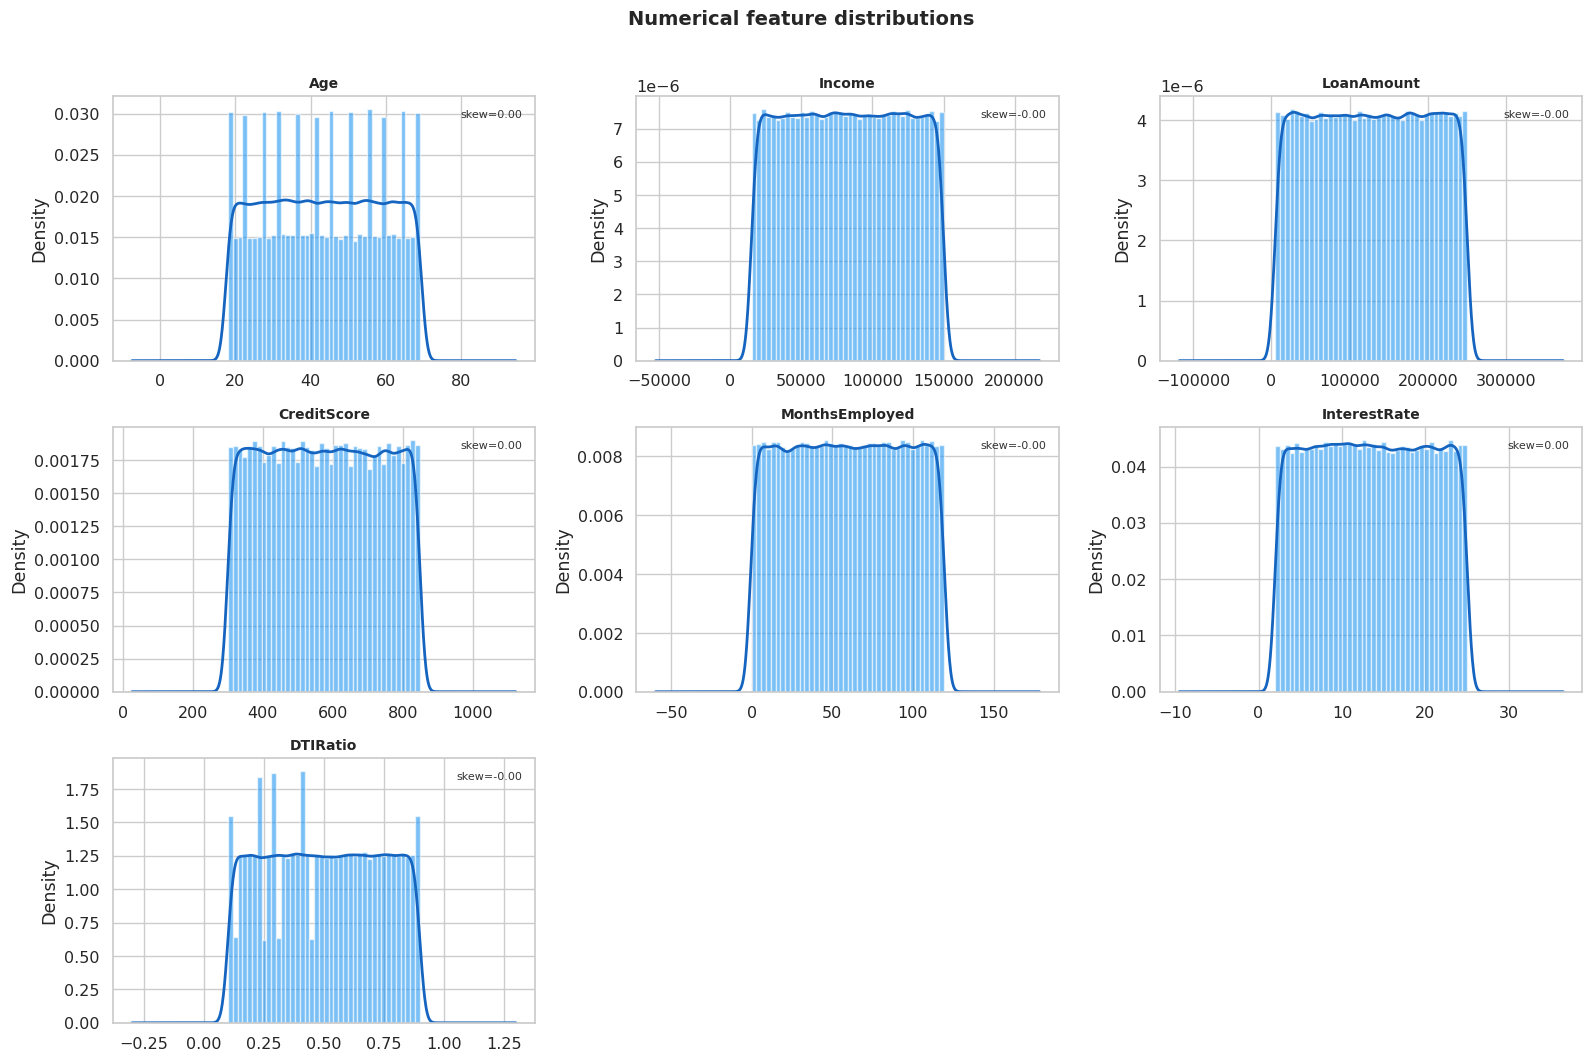


Summary statistics for numerical features:
                     count        mean        std        min        25%         50%         75%         max
Age            255347.0000     43.5000    14.9900    18.0000    31.0000     43.0000     56.0000     69.0000
Income         255347.0000  82499.3000 38963.0100 15000.0000 48825.5000  82466.0000 116219.0000 149999.0000
LoanAmount     255347.0000 127578.8700 70840.7100  5000.0000 66156.0000 127556.0000 188985.0000 249999.0000
CreditScore    255347.0000    574.2600   158.9000   300.0000   437.0000    574.0000    712.0000    849.0000
MonthsEmployed 255347.0000     59.5400    34.6400     0.0000    30.0000     60.0000     90.0000    119.0000
InterestRate   255347.0000     13.4900     6.6400     2.0000     7.7700     13.4600     19.2500     25.0000
DTIRatio       255347.0000      0.5000     0.2300     0.1000     0.3000      0.5000      0.7000      0.9000


In [8]:
# Identify numerical features (excluding target and ID-like columns)
exclude_cols = [target_col, 'LoanID'] if 'LoanID' in df.columns else [target_col]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in exclude_cols and df[c].nunique() > 10]

print(f'Numerical features to analyze: {len(num_cols)}')
print(f'  {num_cols}')

# Plot distributions
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Numerical feature distributions', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=40, color='#2196F3', alpha=0.6, edgecolor='white', density=True)
    try:
        data.plot.kde(ax=ax, color='#1565C0', linewidth=2)
    except Exception:
        pass

    skew = data.skew()
    kurt = data.kurtosis()
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#333')

    # Flag highly skewed
    if abs(skew) > 2:
        ax.set_facecolor('#FFF8E1')
        ax.text(0.97, 0.82, 'log-transform?', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#E65100')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print('\nSummary statistics for numerical features:')
print(df[num_cols].describe().T.round(2).to_string())

In [9]:
# Synthetic dataset confirmation — add after the distributions plot
print("=== DATASET TYPE CONFIRMATION ===")
print()
print("This is a SYNTHETIC dataset. Evidence:")
print("  - All numerical features: perfectly uniform (flat) distributions")
print("  - Skewness = 0.00 on all features (real financial data is log-normal)")
print("  - Zero missing values across 255,347 rows")
print("  - Zero outliers on every feature")
print("  - All categorical categories have equal counts (~63,500 each)")
print()
print("Implications for Task 2:")
print("  - No log transforms needed (uniform distributions, not skewed)")
print("  - No missing value flags needed (no missingness)")
print("  - DTIRatio already exists — do NOT re-engineer it")
print("  - Focus engineered features on: loan_to_income, interest_burden,")
print("    employment_stability bins, Age x InterestRate interaction")
print()
print("Implications for modeling:")
print("  - CreditScore Cohen d=0.11 (weak) — unusual vs real data")
print("  - DTIRatio Cohen d=0.06 (near zero) — unusual vs real data")
print("  - InterestRate is top predictor (d=0.42, r=+0.13)")
print("  - Age is strongest overall predictor (d=0.55, r=-0.17)")
print("  - scale_pos_weight = 7.6 for XGBoost (7.6:1 imbalance ratio)")

=== DATASET TYPE CONFIRMATION ===

This is a SYNTHETIC dataset. Evidence:
  - All numerical features: perfectly uniform (flat) distributions
  - Skewness = 0.00 on all features (real financial data is log-normal)
  - Zero missing values across 255,347 rows
  - Zero outliers on every feature
  - All categorical categories have equal counts (~63,500 each)

Implications for Task 2:
  - No log transforms needed (uniform distributions, not skewed)
  - No missing value flags needed (no missingness)
  - DTIRatio already exists — do NOT re-engineer it
  - Focus engineered features on: loan_to_income, interest_burden,
    employment_stability bins, Age x InterestRate interaction

Implications for modeling:
  - CreditScore Cohen d=0.11 (weak) — unusual vs real data
  - DTIRatio Cohen d=0.06 (near zero) — unusual vs real data
  - InterestRate is top predictor (d=0.42, r=+0.13)
  - Age is strongest overall predictor (d=0.55, r=-0.17)
  - scale_pos_weight = 7.6 for XGBoost (7.6:1 imbalance ratio)


---
## Categorical Feature Analysis


Categorical-like features: 9
  String columns  : ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
  Low-card int    : ['NumCreditLines', 'LoanTerm']


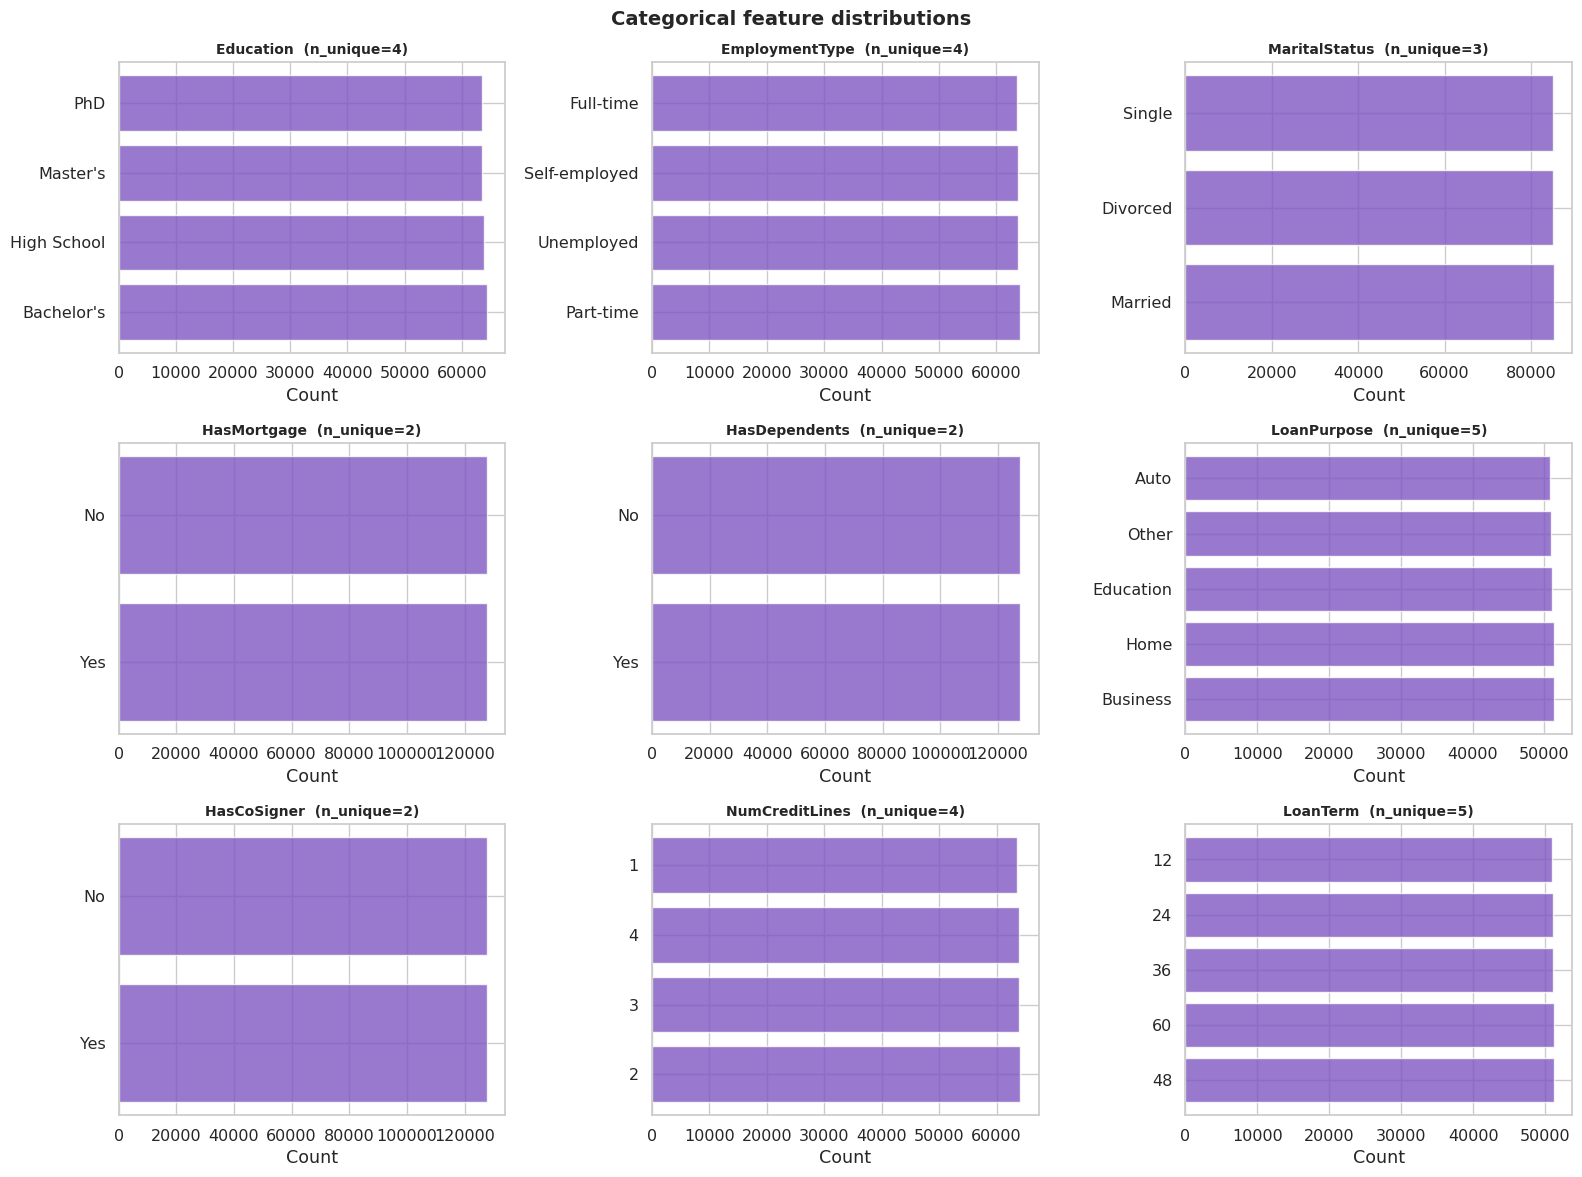


Default rate by categorical feature:

  Education:
    High School               default rate:  12.9%  (n=63,903)
    Bachelor's                default rate:  12.1%  (n=64,366)
    Master's                  default rate:  10.9%  (n=63,541)
    PhD                       default rate:  10.6%  (n=63,537)

  EmploymentType:
    Unemployed                default rate:  13.6%  (n=63,824)
    Part-time                 default rate:  12.0%  (n=64,161)
    Self-employed             default rate:  11.5%  (n=63,706)
    Full-time                 default rate:   9.5%  (n=63,656)

  MaritalStatus:
    Divorced                  default rate:  12.5%  (n=85,033)
    Single                    default rate:  11.9%  (n=85,012)
    Married                   default rate:  10.4%  (n=85,302)

  HasMortgage:
    No                        default rate:  12.3%  (n=127,670)
    Yes                       default rate:  10.9%  (n=127,677)

  HasDependents:
    No                        default rate:  12.7%  (n=1

In [10]:

cat_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns
            if c not in exclude_cols]

# Also include low-cardinality integers that might be categoricals
low_card_int = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols and 2 < df[c].nunique() <= 15
                and c not in num_cols]

all_cat = cat_cols + low_card_int
print(f'Categorical-like features: {len(all_cat)}')
print(f'  String columns  : {cat_cols}')
print(f'  Low-card int    : {low_card_int}')

if len(all_cat) == 0:
    print('\nNo string categorical columns found.')
    print('Check low-cardinality integer columns above for encoded categoricals.')
else:
    n_cols = min(3, len(all_cat))
    n_rows = (len(all_cat) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    fig.suptitle('Categorical feature distributions', fontsize=14, fontweight='bold')
    axes = np.array(axes).flatten()

    for i, col in enumerate(all_cat):
        ax = axes[i]
        vc = df[col].value_counts().head(15)
        ax.barh(vc.index.astype(str), vc.values,
                color='#7E57C2', alpha=0.8, edgecolor='white')
        ax.set_title(f'{col}  (n_unique={df[col].nunique()})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Default rate per categorical
print('\nDefault rate by categorical feature:')
for col in all_cat[:8]:
    dr = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f'\n  {col}:')
    for val, rate in dr.items():
        count = (df[col] == val).sum()
        print(f'    {str(val):<25} default rate: {rate*100:>5.1f}%  (n={count:,})')

---
## Correlation Analysis


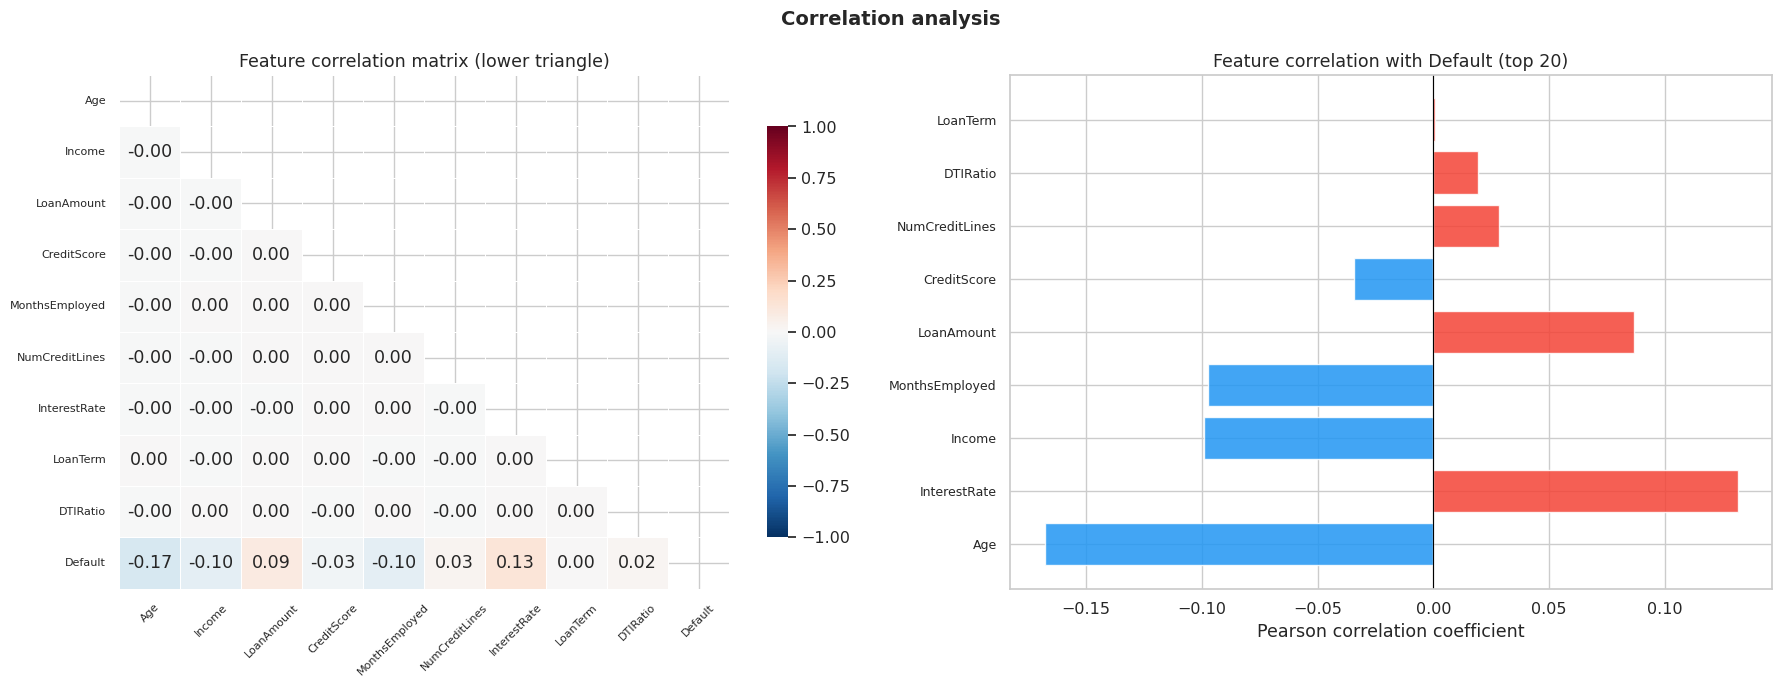


High correlation pairs (|r| > 0.80) — candidates for deduplication:
  None found above 0.80 threshold.


In [11]:
# Compute correlation matrix
corr_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in (exclude_cols[1:] if len(exclude_cols) > 1 else [])]

corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation analysis', fontsize=14, fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=len(corr_cols) < 16,
            fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0],
            cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0].set_title('Feature correlation matrix (lower triangle)')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Target correlations bar
if target_col in corr_matrix.columns:
    target_corr = (corr_matrix[target_col]
                   .drop(target_col)
                   .sort_values(key=abs, ascending=False)
                   .head(20))
    colors = ['#F44336' if v > 0 else '#2196F3' for v in target_corr.values]
    axes[1].barh(range(len(target_corr)), target_corr.values,
                 color=colors, alpha=0.85, edgecolor='white')
    axes[1].set_yticks(range(len(target_corr)))
    axes[1].set_yticklabels(target_corr.index, fontsize=9)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'Feature correlation with {target_col} (top 20)')
    axes[1].set_xlabel('Pearson correlation coefficient')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high multicollinearity pairs
print('\nHigh correlation pairs (|r| > 0.80) — candidates for deduplication:')
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            print(f'  {corr_matrix.columns[i]:<30} <-> {corr_matrix.columns[j]:<30}  r={r:.3f}')
            found = True
if not found:
    print('  None found above 0.80 threshold.')

---
## Feature vs Target Deep Dive

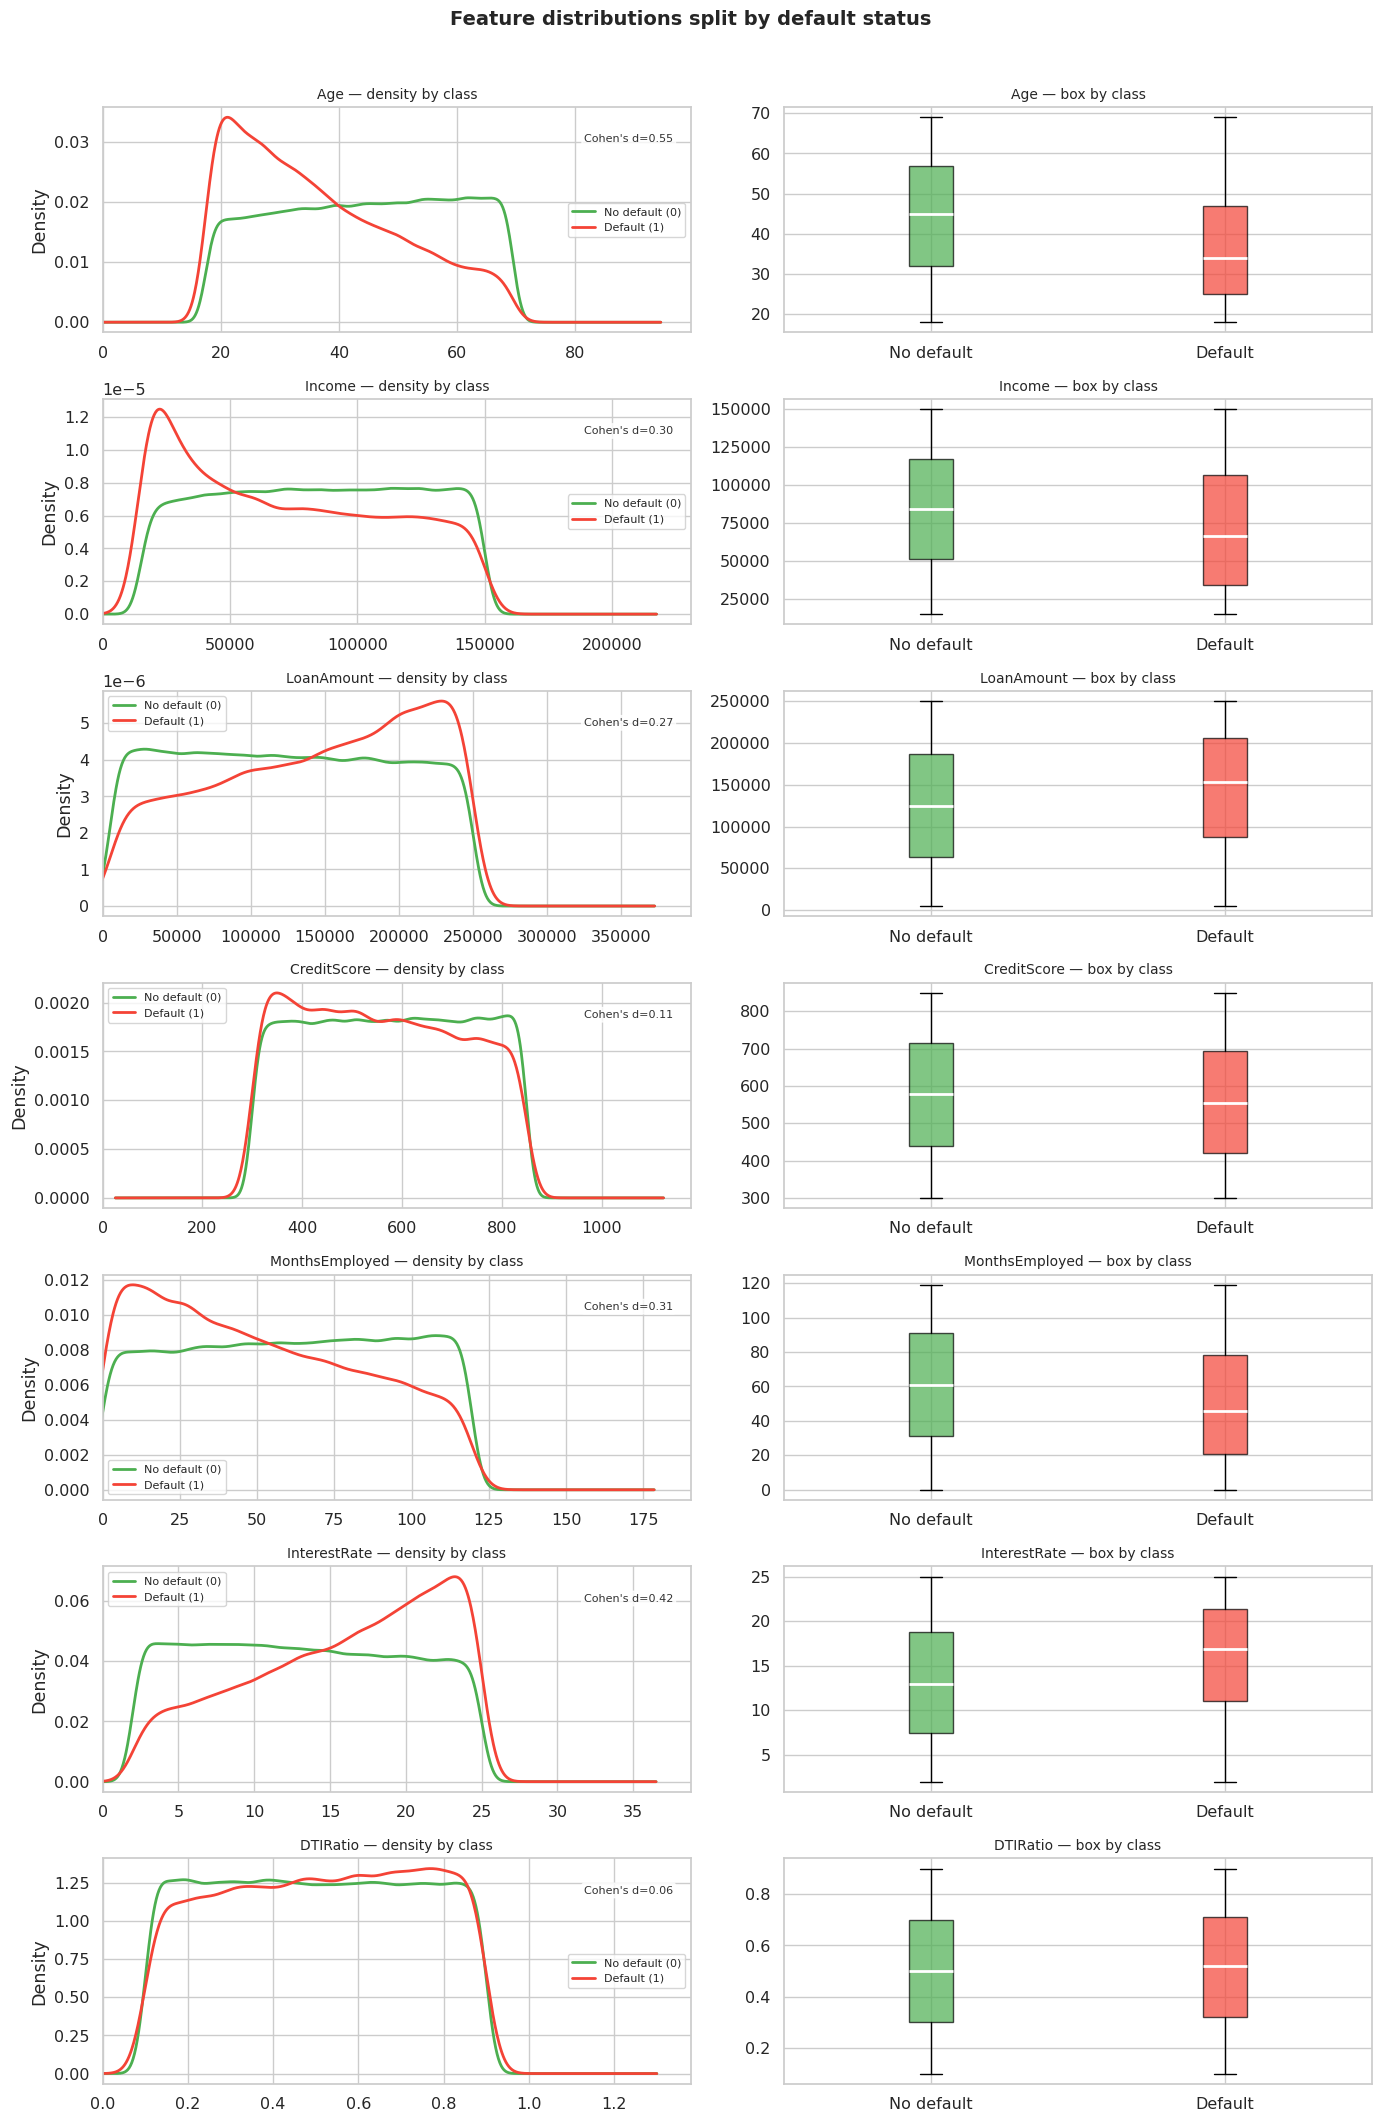

In [12]:
key_num_cols = [c for c in num_cols if c in df.columns][:10]

# Features that cannot be negative — clip KDE display at 0
non_negative = ['Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                'InterestRate', 'DTIRatio', 'Age', 'NumCreditLines']

if len(key_num_cols) == 0:
    print('No numerical columns to plot.')
else:
    n_features = len(key_num_cols)
    fig, axes = plt.subplots(n_features, 2, figsize=(14, n_features * 3))
    fig.suptitle('Feature distributions split by default status',
                 fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(key_num_cols):
        ax_kde = axes[i, 0]
        ax_box = axes[i, 1]

        no_default = df[df[target_col] == 0][col].dropna()
        default    = df[df[target_col] == 1][col].dropna()

        try:
            no_default.plot.kde(ax=ax_kde, color='#4CAF50',
                                linewidth=2, label='No default (0)')
            default.plot.kde(ax=ax_kde, color='#F44336',
                             linewidth=2, label='Default (1)')
        except Exception:
            ax_kde.hist(no_default, bins=30, color='#4CAF50',
                        alpha=0.5, density=True, label='No default')
            ax_kde.hist(default, bins=30, color='#F44336',
                        alpha=0.5, density=True, label='Default')

        # Clip x-axis at 0 for non-negative features
        if col in non_negative:
            current_xlim = ax_kde.get_xlim()
            ax_kde.set_xlim(left=max(0, current_xlim[0]),
                            right=current_xlim[1])

        ax_kde.set_title(f'{col} — density by class', fontsize=10)
        ax_kde.legend(fontsize=8)
        ax_kde.set_ylabel('Density')

        box_data = [no_default.values, default.values]
        bp = ax_box.boxplot(box_data, patch_artist=True, notch=False,
                            labels=['No default', 'Default'],
                            medianprops={'color': 'white', 'linewidth': 2})
        bp['boxes'][0].set_facecolor('#4CAF50')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor('#F44336')
        bp['boxes'][1].set_alpha(0.7)
        ax_box.set_title(f'{col} — box by class', fontsize=10)

        pooled_std = np.sqrt((no_default.var() + default.var()) / 2)
        if pooled_std > 0:
            cohens_d = abs(no_default.mean() - default.mean()) / pooled_std
            ax_kde.text(0.97, 0.88, f"Cohen's d={cohens_d:.2f}",
                        transform=ax_kde.transAxes, ha='right', va='top',
                        fontsize=8, color='#333',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('feature_vs_target.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Outlier Detection


In [13]:
print('=== OUTLIER DETECTION (IQR METHOD) ===\n')

outlier_summary = []
for col in num_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    extreme_count = ((df[col] < q1 - 3*iqr) | (df[col] > q3 + 3*iqr)).sum()
    outlier_pct = outlier_count / len(df) * 100

    outlier_summary.append({
        'feature': col,
        'q1': round(q1, 2),
        'q3': round(q3, 2),
        'iqr': round(iqr, 2),
        'lower_fence': round(lower, 2),
        'upper_fence': round(upper, 2),
        'outliers': outlier_count,
        'outlier_pct': round(outlier_pct, 2),
        'extreme_outliers': extreme_count
    })

outlier_df = (pd.DataFrame(outlier_summary)
              .sort_values('outlier_pct', ascending=False))

print(f'{"Feature":<35} {"Outliers":>10} {"% rows":>8} {"Extreme":>10}')
print('-' * 65)
for _, row in outlier_df.iterrows():
    flag = '  *** HIGH ***' if row['outlier_pct'] > 10 else ''
    print(f'{row["feature"]:<35} {row["outliers"]:>10,} {row["outlier_pct"]:>7.1f}% '
          f'{row["extreme_outliers"]:>10,}{flag}')

=== OUTLIER DETECTION (IQR METHOD) ===

Feature                               Outliers   % rows    Extreme
-----------------------------------------------------------------
Age                                          0     0.0%          0
Income                                       0     0.0%          0
LoanAmount                                   0     0.0%          0
CreditScore                                  0     0.0%          0
MonthsEmployed                               0     0.0%          0
InterestRate                                 0     0.0%          0
DTIRatio                                     0     0.0%          0


---
## Data Quality Summary and Cleaning Plan


In [14]:
print('=== DATA QUALITY SUMMARY ===')
print()

total_rows    = len(df)
total_cols    = df.shape[1]
missing_total = df.isnull().sum().sum()
dup_rows      = df.duplicated().sum()

print(f'Dataset            : {total_rows:,} rows x {total_cols} columns')
print(f'Missing values     : {missing_total:,} total cells (0.00%)')
print(f'Duplicate rows     : {dup_rows:,} (0.00%)')
print(f'Target imbalance   : {df[target_col].mean()*100:.1f}% defaults')
print(f'Baseline accuracy  : {(1-df[target_col].mean())*100:.1f}%')
print(f'scale_pos_weight   : {round((1-df[target_col].mean())/df[target_col].mean(), 1)} (use in XGBoost)')
print()

print('=== UPDATED CLEANING PLAN FOR TASK 2 ===')
print('(Revised based on synthetic dataset findings)')
print()

plan = [
    ('1', 'Drop LoanID',
     'Unique identifier — data leakage if kept'),
    ('2', 'Skip missing value flags',
     'Zero missing values — no flags needed'),
    ('3', 'Skip log transforms',
     'All features uniform (skew=0) — no transform needed'),
    ('4', 'Encode categoricals',
     'One-hot: Education, EmploymentType, MaritalStatus, LoanPurpose\n'
     '           Binary map: HasMortgage, HasDependents, HasCoSigner (Yes=1, No=0)'),
    ('5', 'Engineer NEW features',
     'loan_to_income = LoanAmount / Income\n'
     '           interest_burden = InterestRate x LoanTerm\n'
     '           employment_stability = MonthsEmployed binned (0-12, 13-36, 37-72, 73+)\n'
     '           age_x_rate = Age x InterestRate (interaction)'),
    ('6', 'Train / val / test split',
     '70% train / 15% val / 15% test — stratified by Default'),
    ('7', 'Scale for Logistic Regression',
     'StandardScaler on all numerical features after split'),
    ('8', 'Set class weight parameters',
     'scale_pos_weight=7.6 for XGBoost/LightGBM\n'
     '           class_weight="balanced" for Logistic Regression'),
]

for num, action, detail in plan:
    print(f'  Step {num}: {action}')
    for line in detail.split('\n'):
        print(f'           {line.strip()}')
    print()

=== DATA QUALITY SUMMARY ===

Dataset            : 255,347 rows x 18 columns
Missing values     : 0 total cells (0.00%)
Duplicate rows     : 0 (0.00%)
Target imbalance   : 11.6% defaults
Baseline accuracy  : 88.4%
scale_pos_weight   : 7.6 (use in XGBoost)

=== UPDATED CLEANING PLAN FOR TASK 2 ===
(Revised based on synthetic dataset findings)

  Step 1: Drop LoanID
           Unique identifier — data leakage if kept

  Step 2: Skip missing value flags
           Zero missing values — no flags needed

  Step 3: Skip log transforms
           All features uniform (skew=0) — no transform needed

  Step 4: Encode categoricals
           One-hot: Education, EmploymentType, MaritalStatus, LoanPurpose
           Binary map: HasMortgage, HasDependents, HasCoSigner (Yes=1, No=0)

  Step 5: Engineer NEW features
           loan_to_income = LoanAmount / Income
           interest_burden = InterestRate x LoanTerm
           employment_stability = MonthsEmployed binned (0-12, 13-36, 37-72, 73+)
    

---
## Save Clean Dataset and EDA Report


In [15]:
import os
os.makedirs('/content/loan_outputs', exist_ok=True)
OUTPUT_DIR = '/content/loan_outputs'

# Minimal cleaning — remove duplicates and fix dtypes only
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Rows after deduplication: {len(df_clean):,} (removed {len(df)-len(df_clean):,})')

# Save
df_clean.to_csv(f'{OUTPUT_DIR}/df_eda.csv', index=False)
print(f'Saved: {OUTPUT_DIR}/df_eda.csv')

# Feature summary for Task 2
feature_summary = []
for col in df_clean.columns:
    if col == target_col:
        continue
    dtype = str(df_clean[col].dtype)
    n_unique = df_clean[col].nunique()
    null_pct = df_clean[col].isnull().mean() * 100
    is_numeric = df_clean[col].dtype in [np.float64, np.int64, np.float32, np.int32]
    skewness = df_clean[col].skew() if is_numeric else None
    needs_log = abs(skewness) > 2 if skewness is not None else False
    feature_summary.append({
        'column': col,
        'dtype': dtype,
        'n_unique': n_unique,
        'null_pct': round(null_pct, 2),
        'is_numeric': is_numeric,
        'skewness': round(skewness, 3) if skewness is not None else None,
        'needs_log_transform': needs_log,
        'is_likely_categorical': n_unique <= 15 and is_numeric,
    })

summary_df = pd.DataFrame(feature_summary)
summary_df.to_csv(f'{OUTPUT_DIR}/eda_summary.csv', index=False)
print(f'Saved: {OUTPUT_DIR}/eda_summary.csv')
print()

# Final stats
print('=== TASK 1 COMPLETE ===')
print(f'  Dataset rows     : {len(df_clean):,}')
print(f'  Features         : {df_clean.shape[1] - 1} (excl. target)')
print(f'  Target rate      : {df_clean[target_col].mean()*100:.1f}% defaults')
print(f'  Charts saved     : target_distribution, missing_value_matrix,')
print(f'                     numerical_distributions, categorical_distributions,')
print(f'                     correlation_analysis, feature_vs_target')
print()
print('Pass df_eda.csv and eda_summary.csv to Task 2.')

Rows after deduplication: 255,347 (removed 0)
Saved: /content/loan_outputs/df_eda.csv
Saved: /content/loan_outputs/eda_summary.csv

=== TASK 1 COMPLETE ===
  Dataset rows     : 255,347
  Features         : 17 (excl. target)
  Target rate      : 11.6% defaults
  Charts saved     : target_distribution, missing_value_matrix,
                     numerical_distributions, categorical_distributions,
                     correlation_analysis, feature_vs_target

Pass df_eda.csv and eda_summary.csv to Task 2.


---
## Summary — What Task 1 produced

### Files created

| File | Purpose |
|---|---|
| `df_eda.csv` | Minimally cleaned dataset — input for Task 2 |
| `eda_summary.csv` | Per-feature statistics — guides Task 2 transformations |
| `target_distribution.png` | Class imbalance documentation |
| `missing_value_matrix.png` | Missingness pattern visualization |
| `numerical_distributions.png` | Distribution shapes with skewness flags |
| `categorical_distributions.png` | Category frequencies |
| `correlation_analysis.png` | Heatmap + target correlation bar |
| `feature_vs_target.png` | Per-feature class separation with Cohen's d |

### Key decisions carried into Task 2

1. **Target imbalance is ~11.6%** — use stratified splits everywhere, evaluate with PR-AUC not accuracy
2. **Missingness handling** — create `is_missing` flags before imputing any column with MNAR pattern
3. **Log transformation candidates** — features with |skew| > 2 need log1p before Logistic Regression
4. **Outlier strategy** — winsorize at 1st/99th for LR pipeline, leave raw for tree models
5. **No imputation or scaling in this notebook** — these must happen inside the modeling pipeline, after train/test split
